In [2]:
!pip install pandas matplotlib seaborn scikit-learn xgboost

In [ ]:
!pip install catboost

In [522]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [523]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [524]:
df.shape

(7043, 21)

In [525]:
categorical_features = df.select_dtypes(include=['object']).columns
print(categorical_features)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [526]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [527]:
from sklearn.preprocessing import OneHotEncoder
onehotencoder=OneHotEncoder()



In [528]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [529]:
df.drop(['customerID',],axis=1,inplace=True)

In [530]:
df["MultipleLines"]

,MultipleLines
0,No phone service
1,No
2,No
3,No phone service
4,No
...,...
7038,Yes
7039,Yes
7040,No phone service
7041,Yes


In [531]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['MultipleLines'].value_counts()

,count
MultipleLines,
No,4072
Yes,2971


In [532]:
df["MonthlyCharges"]

,MonthlyCharges
0,29.85
1,56.95
2,53.85
3,42.30
4,70.70
...,...
7038,84.80
7039,103.20
7040,29.60
7041,74.40


In [533]:
median_monthly_charges = df['MonthlyCharges'].median()
df['MonthlyCharges'].fillna(median_monthly_charges, inplace=True)

# Verify that there are no more missing values in 'MonthlyCharges'
print(df['MonthlyCharges'].isnull().sum())

0


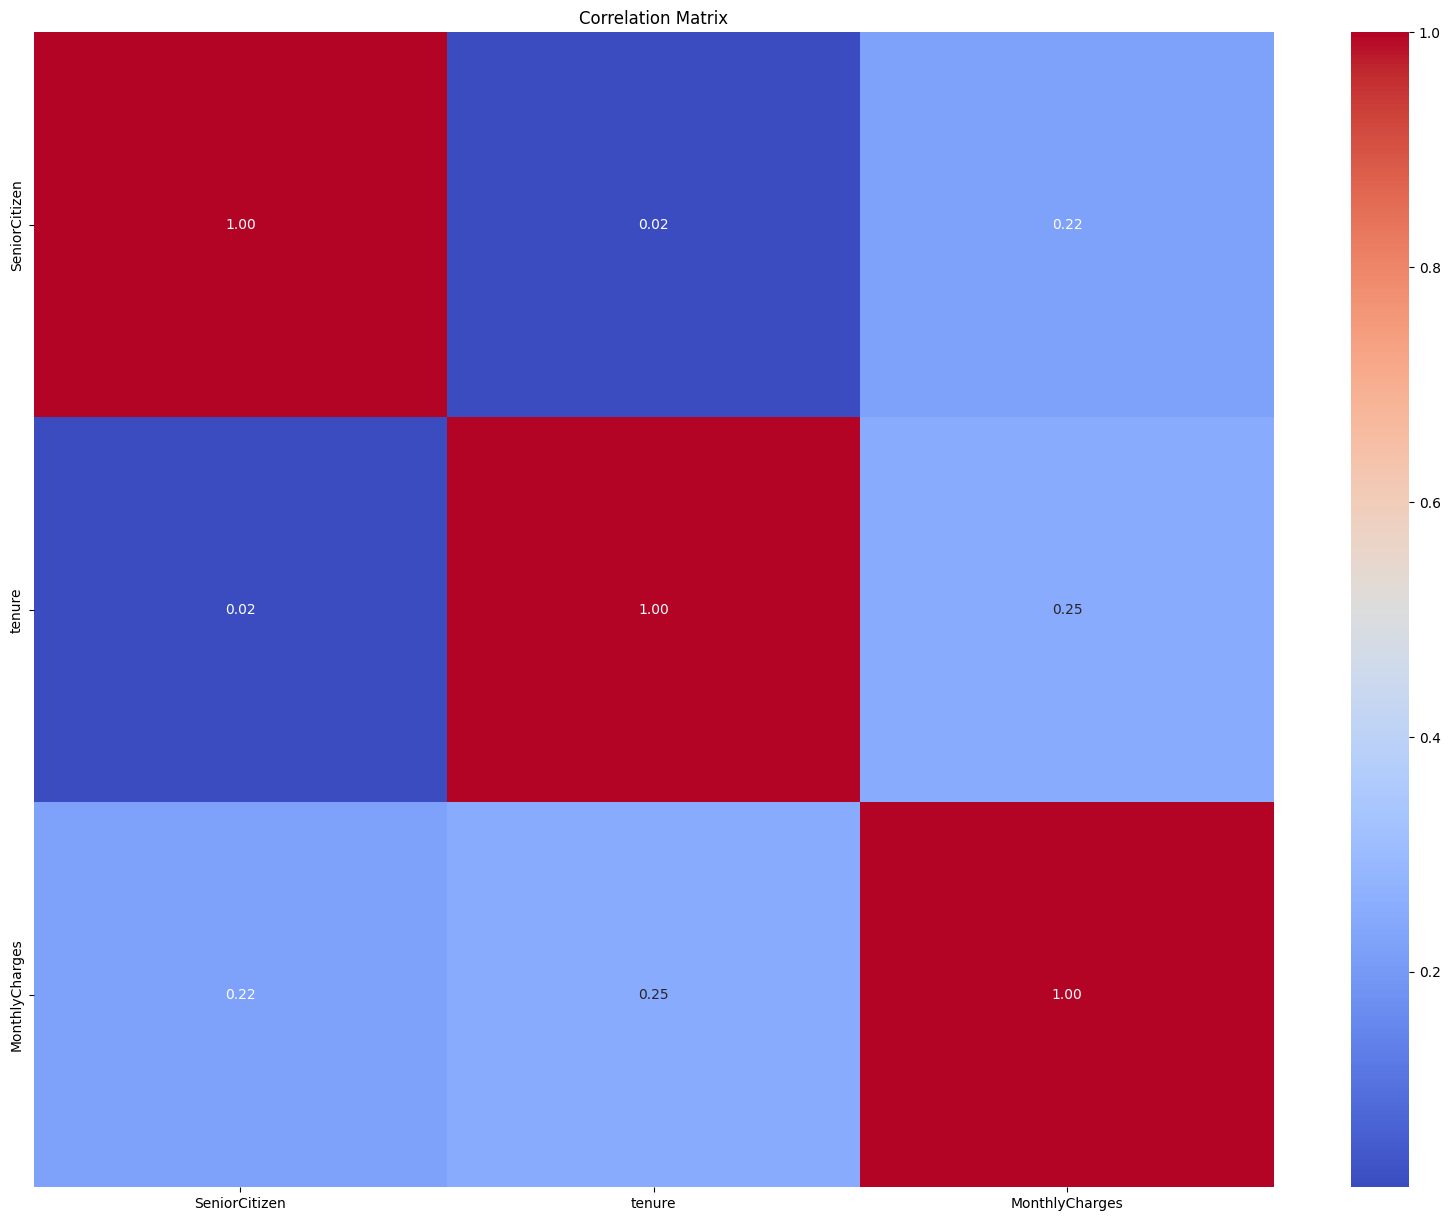

In [534]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [535]:
df['Tenure_MonthlyCharges_Interaction'] = df['tenure'] * df['MonthlyCharges']
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_MonthlyCharges_Interaction
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,1936.30
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40


In [536]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [537]:
print(df["TotalCharges"].isnull().sum())

11


In [538]:

df["TotalCharges"] = (
    df["TotalCharges"]
    .fillna(df["TotalCharges"].median())
)

In [539]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_MonthlyCharges_Interaction
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,2035.20
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,7430.40
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,325.60
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,297.60


In [540]:
categorical_features_to_encode = [feature for feature in categorical_features if feature not in ['customerID', 'TotalCharges', 'Churn']]
print("Categorical features to encode:", categorical_features_to_encode)

Categorical features to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [541]:
# df = df.drop(columns="customerID") # This line is commented out as 'customerID' was already dropped.

In [542]:
encoded_features = onehotencoder.fit_transform(df[categorical_features_to_encode]).toarray()
encoded_feature_names = onehotencoder.get_feature_names_out(categorical_features_to_encode)
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)

df = pd.concat([df.drop(columns=categorical_features_to_encode), df_encoded], axis=1)

In [543]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   Churn                                    7043 non-null   object 
 5   Tenure_MonthlyCharges_Interaction        7043 non-null   float64
 6   gender_Female                            7043 non-null   float64
 7   gender_Male                              7043 non-null   float64
 8   Partner_No                               7043 non-null   float64
 9   Partner_Yes                              7043 non-null   float64
 10  Dependents_No                            7043 no

In [544]:
df["is_new_customer"] = (df["tenure"] < 12).astype(int)

df["high_monthly_charge"] = (
    df["MonthlyCharges"] >
    df["MonthlyCharges"].median()
).astype(int)

df["Service_Count"] = (
    df["PhoneService_Yes"] +
    df["MultipleLines_Yes"] +
    df["InternetService_DSL"] +
    df["InternetService_Fiber optic"] +
    df["OnlineSecurity_Yes"] +
    df["OnlineBackup_Yes"] +
    df["DeviceProtection_Yes"] +
    df["TechSupport_Yes"] +
    df["StreamingTV_Yes"] +
    df["StreamingMovies_Yes"]
)

df["charges_per_service"] = (
    df["MonthlyCharges"] /
    (df["Service_Count"] + 1)
)
df["security_support_score"] = (
    df["OnlineSecurity_Yes"] +
    df["TechSupport_Yes"]
)

In [545]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 51 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   Churn                                    7043 non-null   object 
 5   Tenure_MonthlyCharges_Interaction        7043 non-null   float64
 6   gender_Female                            7043 non-null   float64
 7   gender_Male                              7043 non-null   float64
 8   Partner_No                               7043 non-null   float64
 9   Partner_Yes                              7043 non-null   float64
 10  Dependents_No                            7043 no

In [546]:
X=df.drop('Churn',axis=1)
y=df['Churn']


In [547]:
columns_to_drop = [
    'OnlineBackup_No internet service',
    'TechSupport_No internet service',
    'DeviceProtection_No internet service',
    'StreamingMovies_No internet service',
    'StreamingTV_No internet service'
]

X = X.drop(columns=columns_to_drop)
print(f"Dropped {len(columns_to_drop)} columns with zero importance.")
print(f"New shape of X: {X.shape}")

Dropped 5 columns with zero importance.
New shape of X: (7043, 45)


In [548]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Tenure_MonthlyCharges_Interaction,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,is_new_customer,high_monthly_charge,Service_Count,charges_per_service,security_support_score
0,0,1,29.85,29.85,29.85,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1,0,2.0,9.950000,0.0
1,0,34,56.95,1889.50,1936.30,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0,0,4.0,11.390000,1.0
2,0,2,53.85,108.15,107.70,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,1,0,4.0,10.770000,1.0
3,0,45,42.30,1840.75,1903.50,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0,0,4.0,8.460000,2.0
4,0,2,70.70,151.65,141.40,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1,1,2.0,23.566667,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,2035.20,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0,1,8.0,9.422222,2.0
7039,0,72,103.20,7362.90,7430.40,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0,1,7.0,12.900000,0.0
7040,0,11,29.60,346.45,325.60,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1,0,2.0,9.866667,1.0
7041,1,4,74.40,306.60,297.60,0.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,1,1,3.0,18.600000,0.0


In [549]:
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [550]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [551]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=500
)

In [552]:
y

array([0, 0, 1, ..., 0, 1, 0])

In [553]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

In [554]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [555]:

from catboost import CatBoostClassifier

cbc= CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

In [556]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [557]:
model =lr

In [558]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

In [559]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([0.85447958, 0.84294092, 0.85959596, 0.82516092, 0.83493442])

In [560]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [561]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [562]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall   :", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score :", f1_score(y_test, y_pred, pos_label=1))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


Accuracy : 0.8069552874378992
Precision: 0.6634615384615384
Recall   : 0.553475935828877
F1 Score : 0.6034985422740525
ROC AUC  : 0.8431527551732155


In [563]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="importance",
        ascending=False
    )
)

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'

In [564]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.8081292154774583
Test Accuracy : 0.8069552874378992
